# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [8]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


Po instalacjach udało się zainstalować sterowniki i komputer będzie mógł korzystać z mojej karty graficznej NVIDIA RTX 3060 Ti. PO UZUPEŁNIENIU CAŁEGO KODU Z ZADANIA, MODYFIKUJĘ GO, ABY DOBRAĆ OPTYMALNE HIPERPARAMETRY. ABY NIE SPRAWDZAĆ WIELU KOMBINACJI, NAJPIERW SPRAWDZAM LEARNING RATE I BASE, A POTEM IMAGE_SIZE I _BATCH_SIZE. NA KONIEC NAJLEPSZY WARIANT PUSZCZĘ Z WIĘKSZĄ LICZBĄ EPOK.

## CONFIG

In [21]:
CONFIG = {
    "data_root": "./data_voc",

    "image_size": 64,
    "batch_size": 16,
    "num_workers": 0,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 3e-4,
    "epochs": 20,
    "max_steps_per_epoch": None,
    "base": 32,
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 64, 'batch_size': 16, 'num_workers': 0, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.0003, 'epochs': 20, 'max_steps_per_epoch': None, 'base': 32}


In [22]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

print(len(train_base))
print(len(val_base)) #sprawdzam liczbę przykładów

def create_loaders(image_size, batch_size):
    train_ds = VOCResizeWrapper(train_base, image_size)
    val_ds = VOCResizeWrapper(val_base, image_size)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
    )

    return train_ds, val_ds, train_loader, val_loader


train_ds, val_ds, train_loader, val_loader = create_loaders(128, 8)
img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


1464
1449
img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


Wszystko się zgadza.

### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

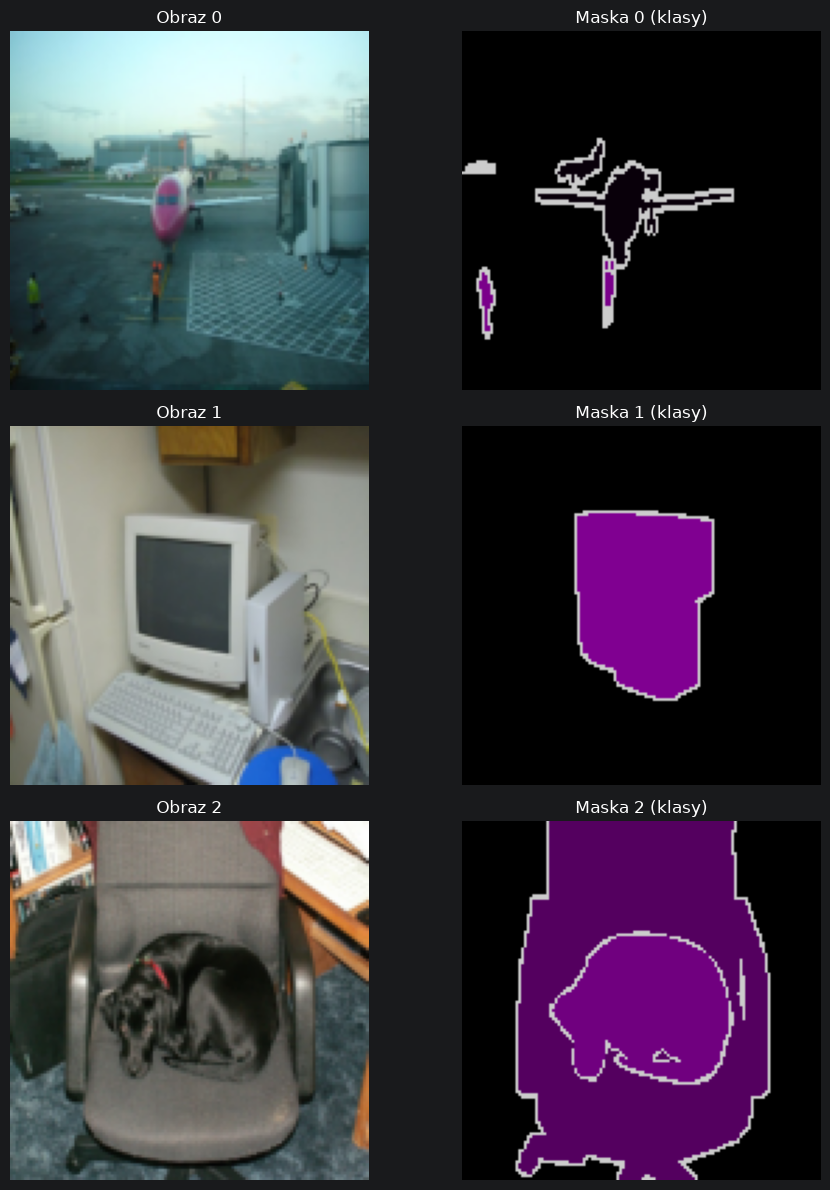

In [23]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

Budujemy U-Neta. Najpierw blok.

In [24]:
class ConvBlock(nn.Module):
    #Blok: [Conv 3x3, BN, ReLU] x 2
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

#Sprawdzam czy wszystko się zgadza:
test_block = ConvBlock(3, 32)

x=torch.randn(8, 3, 128, 128)
y=test_block(x)

print("input:", x.shape)
print("output:", y.shape)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()

        #Encoder
        self.enc1 = ConvBlock(in_channels, base)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = ConvBlock(base, base * 2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        #Bottleneck
        self.bottleneck = ConvBlock(base * 2, base * 4)

        #Decoder
        self.up2 = nn.ConvTranspose2d(
            base * 4,
            base * 2,
            kernel_size=2,
            stride=2
        )

        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(
            base * 2,
            base,
            kernel_size=2,
            stride=2
        )

        self.dec1 = ConvBlock(base * 2, base)

        #Output
        self.final = nn.Conv2d(
            base,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        #Encoder
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        #Bottleneck
        b = self.bottleneck(p2)

        #Decoder ze Skip-Connections
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

#Inicjalizacja modelu
model = SmallUNet(base=CONFIG["base"], num_classes=CONFIG["num_classes"]).to(device)

#Szybki test
dummy = torch.randn(
    CONFIG["batch_size"],
    3,
    CONFIG["image_size"],
    CONFIG["image_size"]
).to(device)

output = model(dummy)

print("Input:", dummy.shape)
print("Output:", output.shape)
print("Device:", output.device)

input: torch.Size([8, 3, 128, 128])
output: torch.Size([8, 32, 128, 128])
Input: torch.Size([16, 3, 64, 64])
Output: torch.Size([16, 21, 64, 64])
Device: cuda:0


Wszystko się zgadza. Przejdę do trenowania modelu.

In [25]:
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()

def train_model():

    #Tworzę datasety i DataLoadery
    train_ds, val_ds, train_loader, val_loader = create_loaders(
        image_size=CONFIG["image_size"],
        batch_size=CONFIG["batch_size"]
    )

    #Tworzę nowy model
    model = SmallUNet(
        base=CONFIG["base"],
        num_classes=CONFIG["num_classes"]
    ).to(device)

    #Tworzę optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["lr"]
    )

    best_val_acc = -1.0

    for epoch in range(CONFIG["epochs"]):

        model.train()
        running = 0.0
        steps = 0

        #Trening
        for step, (imgs, masks) in enumerate(train_loader):

            if CONFIG["max_steps_per_epoch"] is not None:
                if step >= CONFIG["max_steps_per_epoch"]:
                    break

            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(imgs)
            loss = criterion(logits, masks)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running += loss.item()
            steps += 1

        #Walidacja
        model.eval()
        accs = []

        with torch.no_grad():

            for imgs, masks in val_loader:

                imgs = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                logits = model(imgs)

                accs.append(
                    pixel_accuracy(logits, masks)
                )

        val_acc = float(np.mean(accs))
        train_loss = running / max(1, steps)

        best_val_acc = max(
            best_val_acc,
            val_acc
        )

        print(
            f"Epoch {epoch+1}/{CONFIG['epochs']} | "
            f"train_loss={train_loss:.4f} | "
            f"val_pixel_acc={val_acc:.4f}"
        )

    print("\n" + "=" * 60)
    print("KOŃCOWY WYNIK")
    print("=" * 60)

    print("lr:", CONFIG["lr"])
    print("base:", CONFIG["base"])
    print("image_size:", CONFIG["image_size"])
    print("batch_size:", CONFIG["batch_size"])
    print("epochs:", CONFIG["epochs"])
    print("best_val_acc:", best_val_acc)

    return best_val_acc, model

best_val_acc, model = train_model()

#tym sprawdzałem 2 parametry (późniejsze, 2 pierwsze niżej)
# def train_model(lr, base, image_size, batch_size):
#
#     #Tworzę DataLoadery dla konkretnej kombinacji
#     train_ds, val_ds, train_loader, val_loader = create_loaders(
#         image_size=image_size,
#         batch_size=batch_size
#     )
#
#     #Tworzę nowy model dla każdej kombinacji parametrów
#     model = SmallUNet(
#         base=base,
#         num_classes=CONFIG["num_classes"]
#     ).to(device)
#
#     #Nowy optimizer dla nowego modelu
#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=lr
#     )
#
#     best_val_acc = -1.0
#
#     for epoch in range(CONFIG["epochs"]):
#
#         model.train()
#         running = 0.0
#         steps = 0
#
#         #Trening
#         for step, (imgs, masks) in enumerate(train_loader):
#
#             if CONFIG["max_steps_per_epoch"] is not None:
#                 if step >= CONFIG["max_steps_per_epoch"]:
#                     break
#
#             imgs = imgs.to(device, non_blocking=True)
#             masks = masks.to(device, non_blocking=True)
#
#             logits = model(imgs)
#             loss = criterion(logits, masks)
#
#             optimizer.zero_grad(set_to_none=True)
#             loss.backward()
#             optimizer.step()
#
#             running += loss.item()
#             steps += 1
#
#         #Walidacja
#         model.eval()
#         accs = []
#
#         with torch.no_grad():
#
#             for imgs, masks in val_loader:
#
#                 imgs = imgs.to(device, non_blocking=True)
#                 masks = masks.to(device, non_blocking=True)
#
#                 logits = model(imgs)
#
#                 accs.append(
#                     pixel_accuracy(logits, masks)
#                 )
#
#         val_acc = float(np.mean(accs))
#         train_loss = running / max(1, steps)
#
#         best_val_acc = max(
#             best_val_acc,
#             val_acc
#         )
#
#         print(
#             f"Epoch {epoch+1}/{CONFIG['epochs']} | "
#             f"lr={lr} | "
#             f"base={base} | "
#             f"image_size={image_size} | "
#             f"batch_size={batch_size} | "
#             f"train_loss={train_loss:.4f} | "
#             f"val_pixel_acc={val_acc:.4f}"
#         )
#
#     print(
#         f"BEST | "
#         f"lr={lr} | "
#         f"base={base} | "
#         f"image_size={image_size} | "
#         f"batch_size={batch_size} | "
#         f"best_val_acc={best_val_acc:.4f}"
#     )
#     return best_val_acc, model
#
# #Wartości do sprawdzenia
# image_size_values = [64, 96, 128, 160, 192]
# batch_size_values = [4, 8, 12, 16, 20]
#
# #Najlepsze parametry znalezione w poprzednim eksperymencie
# best_lr = 3e-4
# best_base = 32
#
# results = []
#
# for image_size in image_size_values:
#     for batch_size in batch_size_values:
#
#         print("\n" + "=" * 60)
#         print(
#             f"START: image_size={image_size}, "
#             f"batch_size={batch_size}"
#         )
#         print("=" * 60)
#
#         best_val_acc, model = train_model(
#             lr=best_lr,
#             base=best_base,
#             image_size=image_size,
#             batch_size=batch_size
#         )
#
#         results.append({
#             "image_size": image_size,
#             "batch_size": batch_size,
#             "best_val_acc": best_val_acc
#         })
#
# best_result = max(
#     results,
#     key=lambda x: x["best_val_acc"]
# )
#
# print("\n" + "=" * 60)
# print("NAJLEPSZA KOMBINACJA")
# print("=" * 60)
#
# print("image_size:", best_result["image_size"])
# print("batch_size:", best_result["batch_size"])
# print("best_val_acc:", best_result["best_val_acc"])


#Tym sprawdzałem dwa pierwsze hiperparametry:
# def train_model(lr, base):
#     #Tworzę nowy model dla każdej kombinacji parametrów
#     model = SmallUNet(base=base,num_classes=CONFIG["num_classes"]).to(device)
#
#     #Nowy optimizer dla nowego modelu
#     optimizer = torch.optim.Adam(#kolega Adam będzie zmniejszał wartość funkcji straty,bo będzie zmieniał wagi sieci
#         model.parameters(),lr=lr)
#
#     best_val_acc = -1.0
#
#     for epoch in range(CONFIG["epochs"]):
#         model.train()
#         running = 0.0
#         steps = 0
#
#         #Trening
#         for step, (imgs, masks) in enumerate(train_loader):
#
#             if CONFIG["max_steps_per_epoch"] is not None:
#                 if step >= CONFIG["max_steps_per_epoch"]:
#                     break
#
#             imgs = imgs.to(device, non_blocking=True)
#             masks = masks.to(device, non_blocking=True)
#
#             logits = model(imgs)
#             loss = criterion(logits, masks)
#
#             optimizer.zero_grad(set_to_none=True)
#             loss.backward()
#             optimizer.step()
#
#             running += loss.item()
#             steps += 1
#
#         #Walidacja
#         model.eval()
#         accs = []
#
#         with torch.no_grad():
#             for imgs, masks in val_loader:
#                 imgs = imgs.to(device, non_blocking=True)
#                 masks = masks.to(device, non_blocking=True)
#
#                 logits = model(imgs)
#                 accs.append(pixel_accuracy(logits, masks))
#
#         val_acc = float(np.mean(accs))
#         train_loss = running / max(1, steps)
#
#         best_val_acc = max(best_val_acc, val_acc)
#
#         print(
#             f"Epoch {epoch+1}/{CONFIG['epochs']} | "
#             f"lr={lr} | base={base} | "
#             f"train_loss={train_loss:.4f} | "
#             f"val_pixel_acc={val_acc:.4f}"
#         )
#
#     print(
#         f"BEST | lr={lr} | base={base} | "
#         f"best_val_acc={best_val_acc:.4f}"
#     )
#
#     return best_val_acc, model
#
# #Wartosci do sprawdzenia
# lr_values = [1e-4, 3e-4, 5e-4, 1e-3, 3e-3]
# base_values = [8, 16, 24, 32, 48]
#
# results=[]
#
# for lr in lr_values:
#     for base in base_values:
#
#         print("\n" + "=" * 60)
#         print(f"START: lr={lr}, base={base}")
#         print("=" * 60)
#
#         best_val_acc, model = train_model(
#             lr=lr,
#             base=base
#         )
#
#         results.append({
#             "lr": lr,
#             "base": base,
#             "best_val_acc": best_val_acc
#         })
#
# best_result = max(results, key=lambda x: x["best_val_acc"])
#
# print("\n" + "=" * 60)
# print("NAJLEPSZA KOMBINACJA")
# print("=" * 60)
# print("lr:", best_result["lr"])
# print("base:", best_result["base"])
# print("best_val_acc:", best_result["best_val_acc"])

Epoch 1/20 | train_loss=2.3371 | val_pixel_acc=0.6337
Epoch 2/20 | train_loss=1.7986 | val_pixel_acc=0.5882
Epoch 3/20 | train_loss=1.5045 | val_pixel_acc=0.7309
Epoch 4/20 | train_loss=1.3212 | val_pixel_acc=0.7274
Epoch 5/20 | train_loss=1.2160 | val_pixel_acc=0.7257
Epoch 6/20 | train_loss=1.1675 | val_pixel_acc=0.7365
Epoch 7/20 | train_loss=1.1284 | val_pixel_acc=0.7357
Epoch 8/20 | train_loss=1.1010 | val_pixel_acc=0.7345
Epoch 9/20 | train_loss=1.0743 | val_pixel_acc=0.7347
Epoch 10/20 | train_loss=1.0535 | val_pixel_acc=0.7358
Epoch 11/20 | train_loss=1.0381 | val_pixel_acc=0.7395
Epoch 12/20 | train_loss=1.0245 | val_pixel_acc=0.7354
Epoch 13/20 | train_loss=0.9979 | val_pixel_acc=0.7253
Epoch 14/20 | train_loss=0.9892 | val_pixel_acc=0.7387
Epoch 15/20 | train_loss=0.9775 | val_pixel_acc=0.7414
Epoch 16/20 | train_loss=0.9519 | val_pixel_acc=0.7320
Epoch 17/20 | train_loss=0.9352 | val_pixel_acc=0.7439
Epoch 18/20 | train_loss=0.9272 | val_pixel_acc=0.7219
Epoch 19/20 | train

Okazuje się, że parametr num_workers muszę zmienić na 0. Przy np 2, kod nie wykonał się przez 4h. Widziałem też, że nie tylko mnie dotyczy ten problem. Sukces. Model się uczy.

### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

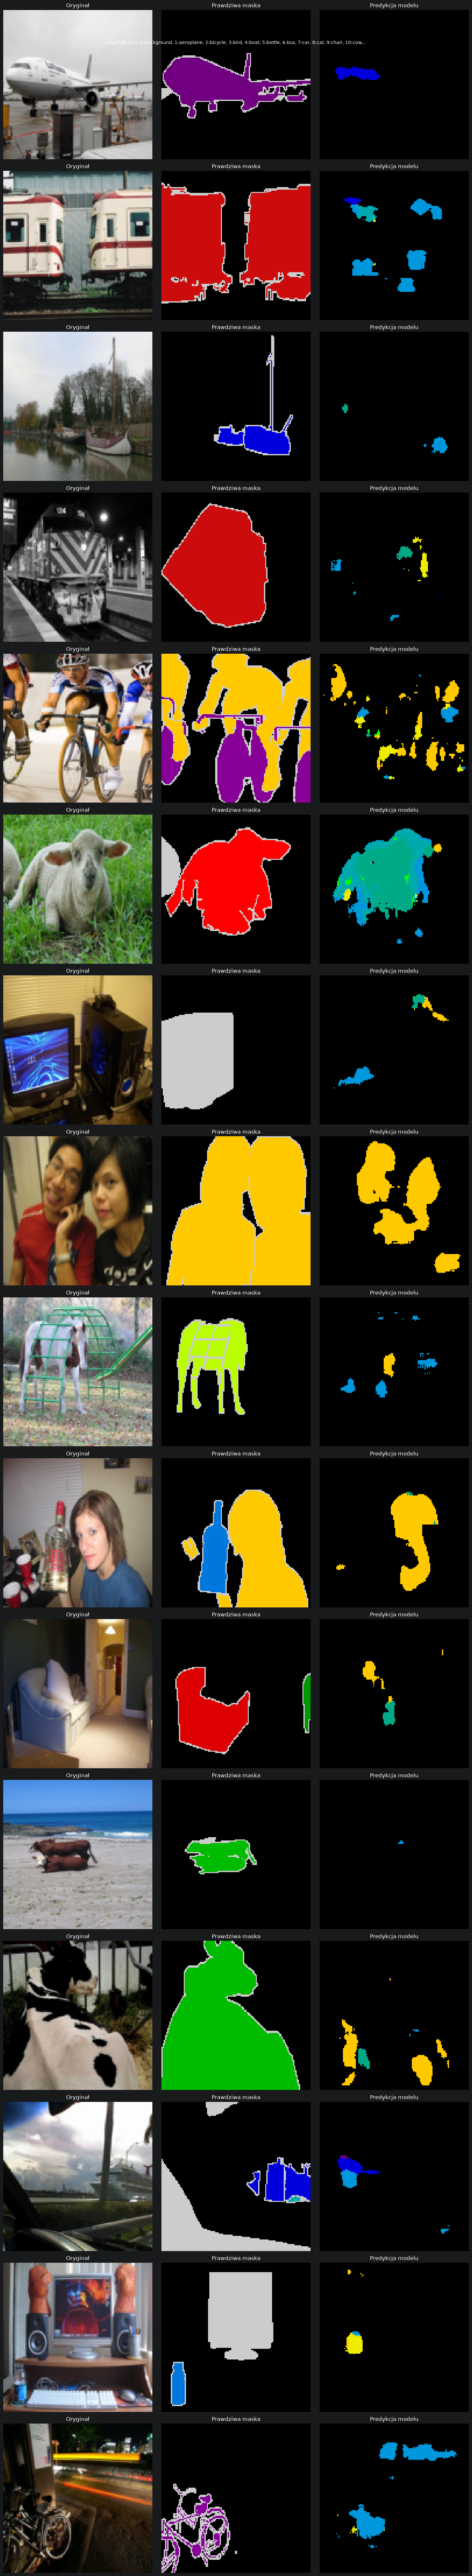

In [26]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=16):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

Wyniki nie są oszałamiające, ale lepsze niż dla pierwotnych parametrów.